In [28]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/AI&ML project/Colab Notebooks/Churn_Modelling.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [29]:
!pip install catboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, classification_report,
                             precision_recall_curve, average_precision_score)

from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

# Keep plots readable
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

In [30]:
# CELL 3: DATA PREPROCESSING
# ============================================================

# --- 3.1 Basic structural check ---
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# --- 3.2 Drop identifier columns that carry no predictive signal ---
# RowNumber, CustomerId, Surname are unique per customer and don't
# generalize -> keeping them would let the model "memorize" rather
# than learn genuine churn patterns (data leakage risk / noise).
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# --- 3.3 Check target class balance (important: this dataset IS imbalanced) ---
print("\nTarget distribution:\n", df['Exited'].value_counts(normalize=True))

# --- 3.4 Convert categorical columns to proper 'category' dtype ---
# CatBoost works best when categorical features are explicitly
# declared (no need to one-hot/label encode manually - CatBoost
# handles categorical splits internally, which reduces overfitting
# risk vs. one-hot encoding on high-cardinality columns).
categorical_cols = ['Geography', 'Gender']
for col in categorical_cols:
    df[col] = df[col].astype(str)  # CatBoost expects string/category dtype


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing values per column:
 RowNumber          0
CustomerId         0
Surname            0
Cr

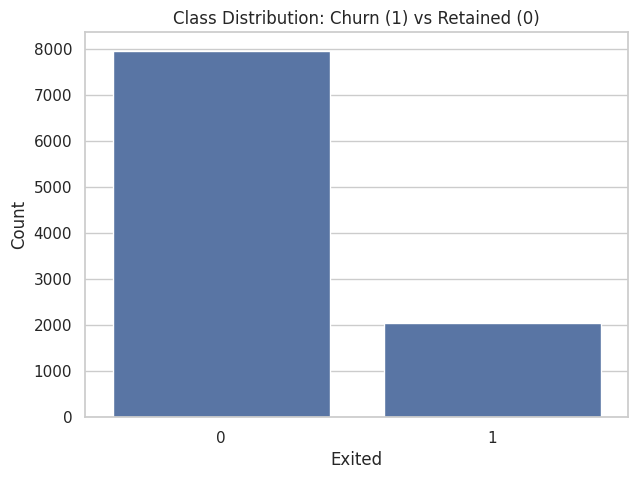

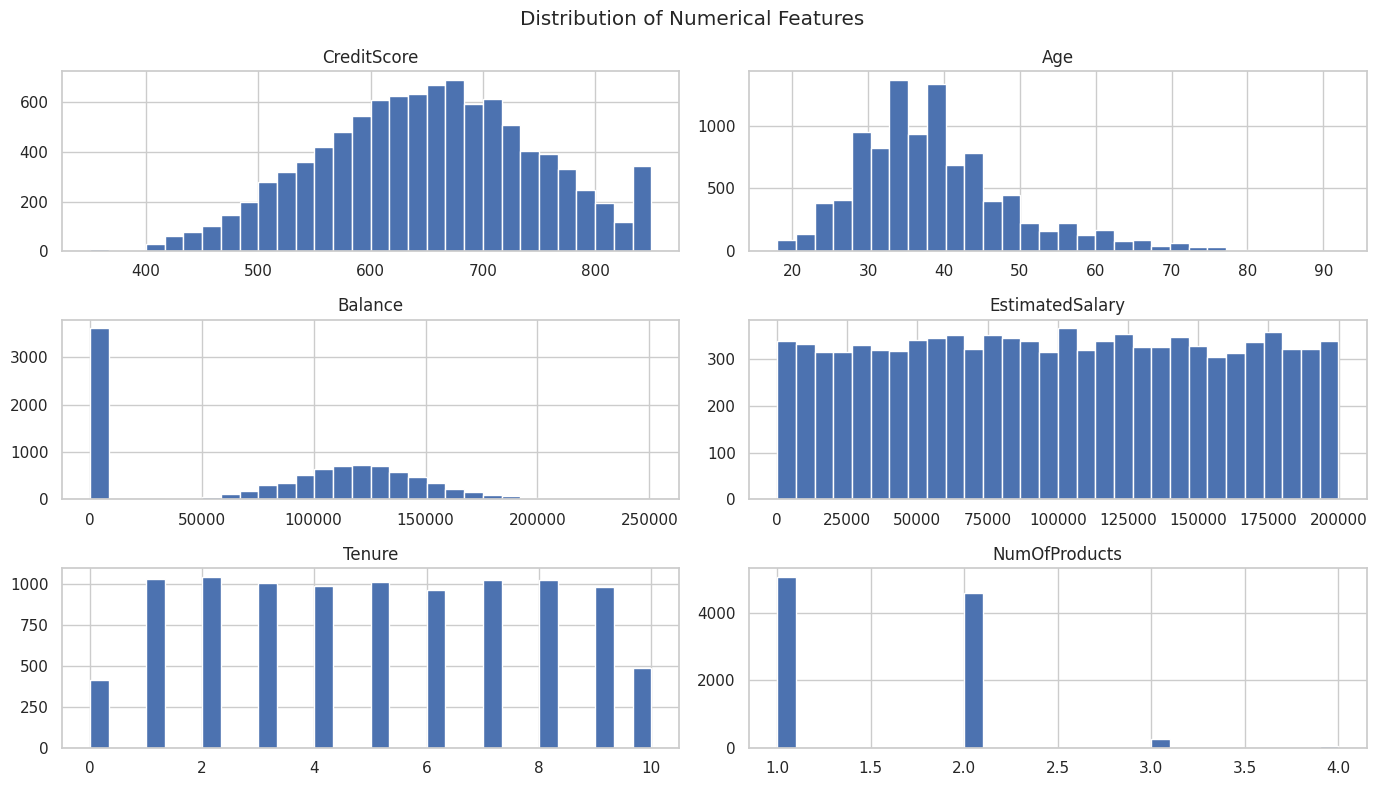

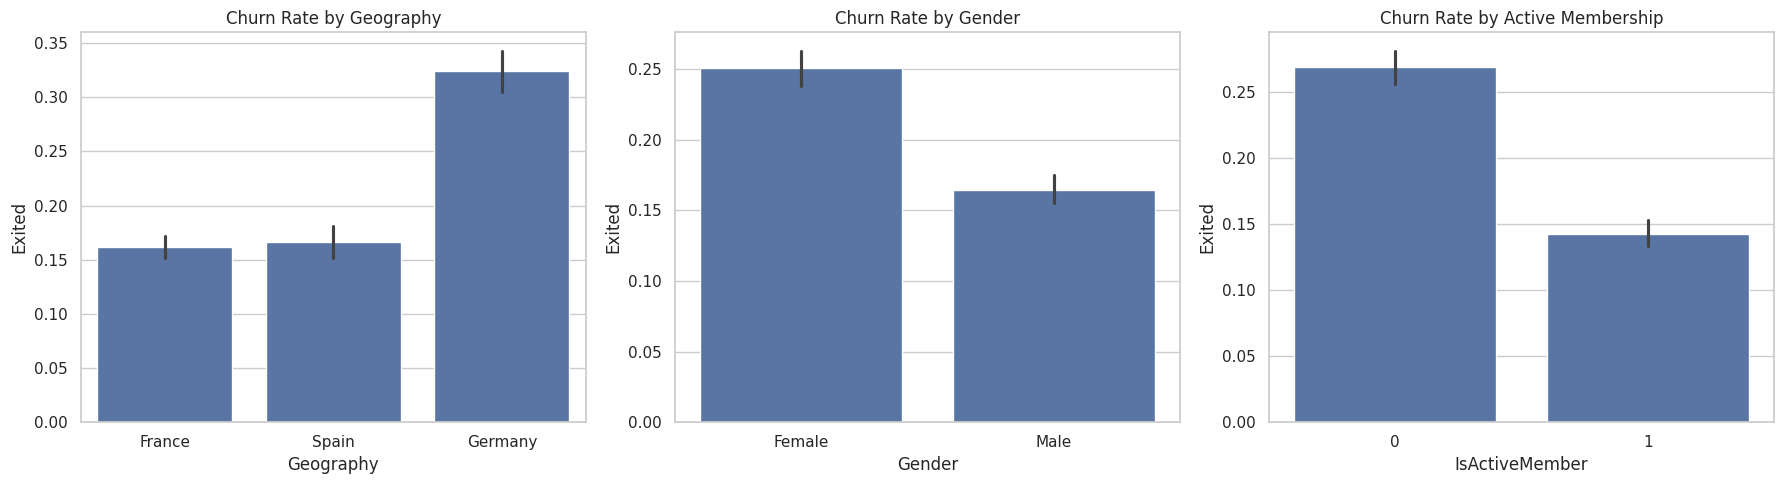

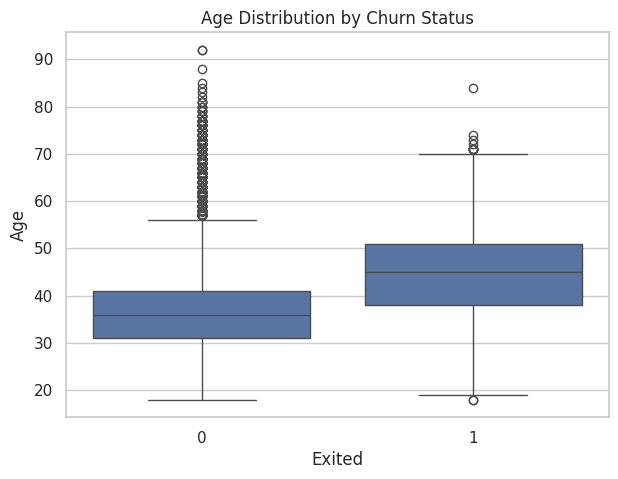

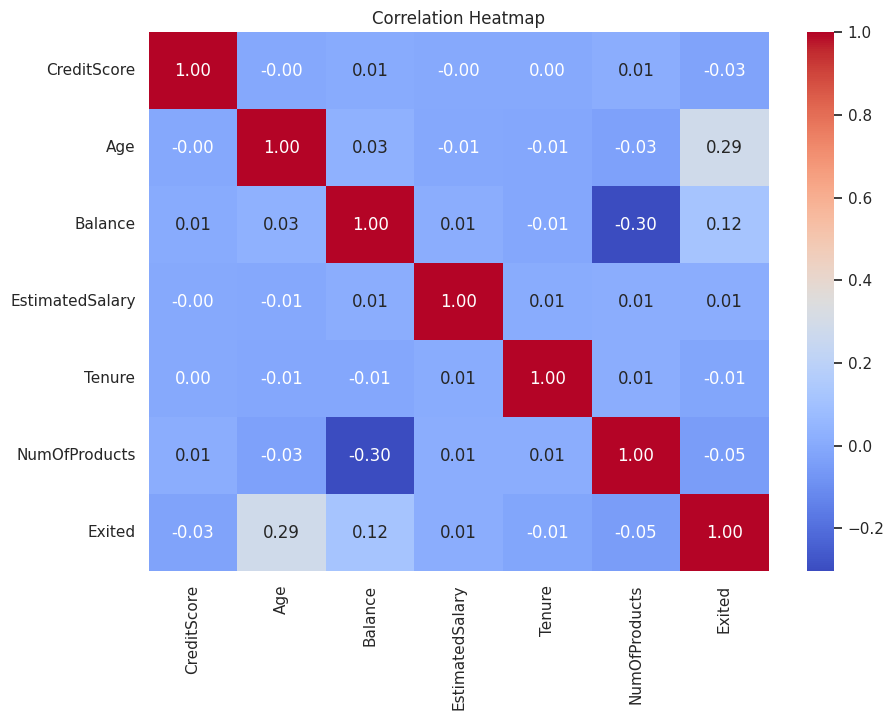

Churn rate by balance status:
  Non-zero balance: 24.08%
  Zero balance:     13.82%


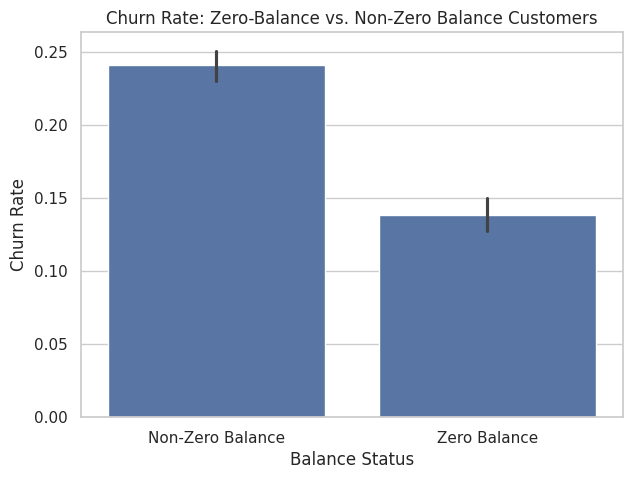

In [31]:
#CELL 4: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# --- 4.1 Target imbalance visualization ---
plt.figure()
sns.countplot(x='Exited', data=df)
plt.title("Class Distribution: Churn (1) vs Retained (0)")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()

# --- 4.2 Numerical feature distributions ---
num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']
df[num_cols].hist(bins=30, figsize=(14, 8))
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

# --- 4.3 Churn rate by categorical features ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x='Geography', y='Exited', data=df, ax=axes[0])
axes[0].set_title("Churn Rate by Geography")

sns.barplot(x='Gender', y='Exited', data=df, ax=axes[1])
axes[1].set_title("Churn Rate by Gender")

sns.barplot(x='IsActiveMember', y='Exited', data=df, ax=axes[2])
axes[2].set_title("Churn Rate by Active Membership")
plt.tight_layout()
plt.show()

# --- 4.4 Age vs Churn (boxplot) ---
# Older customers often show different churn behavior - worth inspecting.
plt.figure()
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age Distribution by Churn Status")
plt.show()

# --- 4.5 Correlation heatmap (numerical features only) ---
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols + ['Exited']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# --- 4.6 Churn rate: Zero-balance vs. Non-zero balance customers ---
# Checks whether the ~36% of customers with Balance=0 churn at a
# meaningfully different rate than the rest - this directly explains
# why IsZeroBalance was engineered as a feature in Cell 5.

df['IsZeroBalance_temp'] = (df['Balance'] == 0).astype(int)  # temp version for EDA, since Cell 5 hasn't run yet at this point in the notebook

zero_balance_churn = df.groupby('IsZeroBalance_temp')['Exited'].mean()
print("Churn rate by balance status:")
print(f"  Non-zero balance: {zero_balance_churn[0]:.2%}")
print(f"  Zero balance:     {zero_balance_churn[1]:.2%}")

plt.figure()
sns.barplot(x='IsZeroBalance_temp', y='Exited', data=df)
plt.xticks([0, 1], ['Non-Zero Balance', 'Zero Balance'])
plt.xlabel("Balance Status")
plt.ylabel("Churn Rate")
plt.title("Churn Rate: Zero-Balance vs. Non-Zero Balance Customers")
plt.show()

df = df.drop(columns=['IsZeroBalance_temp'])  # cleanup - the real IsZeroBalance gets created properly in Cell 5



In [32]:
# ============================================================
# CELL 4B: EDA — NUMERIC SUMMARY (no diagrams, text-only output)
# ============================================================
# Companion to Cell 4's visual EDA - same insights, but as printed
# tables/numbers for precise, unambiguous review (useful when sharing
# results as text rather than images).

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# --- 1. Class distribution ---
print("="*60)
print("1. CLASS DISTRIBUTION (Exited)")
print("="*60)
print(df['Exited'].value_counts())
print((df['Exited'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# --- 2. Numerical feature summary stats ---
print("\n" + "="*60)
print("2. NUMERICAL FEATURE SUMMARY STATISTICS")
print("="*60)
num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']
print(df[num_cols].describe().round(2))

# --- 3. Value counts for lower-cardinality numeric/categorical columns ---
print("\n" + "="*60)
print("3. VALUE COUNTS — Tenure, NumOfProducts, Geography, Gender")
print("="*60)
for col in ['Tenure', 'NumOfProducts', 'Geography', 'Gender', 'HasCrCard', 'IsActiveMember']:
    print(f"\n--- {col} ---")
    counts = df[col].value_counts().sort_index()
    pct = (df[col].value_counts(normalize=True).sort_index() * 100).round(2)
    summary = pd.DataFrame({'Count': counts, 'Percent': pct})
    print(summary)

# --- 4. Churn rate by category (numeric version of the bar charts) ---
print("\n" + "="*60)
print("4. CHURN RATE BY CATEGORY")
print("="*60)
for col in ['Geography', 'Gender', 'IsActiveMember', 'HasCrCard', 'Tenure', 'NumOfProducts']:
    print(f"\n--- Churn rate by {col} ---")
    churn_rate = (df.groupby(col)['Exited'].mean() * 100).round(2)
    counts = df.groupby(col).size()
    summary = pd.DataFrame({'ChurnRate%': churn_rate, 'CustomerCount': counts})
    print(summary)

# --- 5. Churn rate by zero-balance status ---
print("\n" + "="*60)
print("5. CHURN RATE BY BALANCE STATUS")
print("="*60)
df['_temp_zero_bal'] = (df['Balance'] == 0).astype(int)
churn_by_balance = (df.groupby('_temp_zero_bal')['Exited'].mean() * 100).round(2)
print(f"Non-zero balance churn rate: {churn_by_balance[0]}%")
print(f"Zero balance churn rate:     {churn_by_balance[1]}%")
df = df.drop(columns=['_temp_zero_bal'])

# --- 6. Age distribution by churn status (numeric boxplot equivalent) ---
print("\n" + "="*60)
print("6. AGE DISTRIBUTION BY CHURN STATUS (quartiles)")
print("="*60)
print(df.groupby('Exited')['Age'].describe().round(2))

# --- 7. Correlation matrix (numeric version of heatmap) ---
print("\n" + "="*60)
print("7. CORRELATION MATRIX (numerical features + target)")
print("="*60)
print(df[num_cols + ['Exited']].corr().round(3))

# --- 8. Skewness check (flags potential synthetic/uniform distributions) ---
print("\n" + "="*60)
print("8. SKEWNESS CHECK (near-zero skew on non-normal data can indicate synthetic/uniform generation)")
print("="*60)
print(df[num_cols].skew().round(3))

1. CLASS DISTRIBUTION (Exited)
Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63%
1    20.37%
Name: proportion, dtype: object

2. NUMERICAL FEATURE SUMMARY STATISTICS
       CreditScore       Age    Balance  EstimatedSalary    Tenure  NumOfProducts
count     10000.00  10000.00   10000.00         10000.00  10000.00       10000.00
mean        650.53     38.92   76485.89        100090.24      5.01           1.53
std          96.65     10.49   62397.41         57510.49      2.89           0.58
min         350.00     18.00       0.00            11.58      0.00           1.00
25%         584.00     32.00       0.00         51002.11      3.00           1.00
50%         652.00     37.00   97198.54        100193.92      5.00           1.00
75%         718.00     44.00  127644.24        149388.25      7.00           2.00
max         850.00     92.00  250898.09        199992.48     10.00           4.00

3. VALUE COUNTS — Tenure, NumOfProducts, Geography, Gender

--- Tenure --

In [43]:
# CELL 5: FEATURE ENGINEERING
# ============================================================

# --- 5.1 Balance-to-Salary ratio ---
# Captures financial "cushion" relative to income - customers with
# high balance relative to salary may behave differently.
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)  # +1 avoids div-by-zero

# --- 5.2 Zero-balance flag ---
# A meaningful chunk of customers have Balance = 0 (common in this
# dataset) - flagging it lets the model treat "no balance" as a
# distinct behavioral signal rather than just a low number.
df['IsZeroBalance'] = (df['Balance'] == 0).astype(int)

# --- 5.3 Age groups (bucketing) ---
# Helps the model capture non-linear age-related churn patterns
# (e.g., middle-aged customers churning more) more explicitly.
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 100],
                         labels=['18-30', '31-40', '41-50', '51-60', '60+'])
df['AgeGroup'] = df['AgeGroup'].astype(str)

# --- 5.4 Products per tenure year (engagement intensity) ---
# Ratio of products held to how long they've been a customer;
# a proxy for engagement/cross-sell success rate.
df['ProductsPerTenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

'''# --- 5.5 Update categorical column list to include new engineered ones ---
categorical_cols = ['Geography', 'Gender', 'AgeGroup']

print("Engineered feature preview:")
df[['BalanceSalaryRatio', 'IsZeroBalance', 'AgeGroup', 'ProductsPerTenure']].head()'''

# --- 5.6 Interaction features ---

# Inactive + older customers are highest churn risk - this combo isn't
# captured by Age or IsActiveMember individually.
df['Age_Inactive'] = df['Age'] * (1 - df['IsActiveMember'])

# NumOfProducts has a NON-linear relationship with churn (heatmap shows
# near-zero linear correlation, but 3-4 products often signals a
# struggling/over-sold customer) - treating it as categorical lets
# CatBoost split on this pattern directly instead of assuming a straight line.
df['NumOfProducts_cat'] = df['NumOfProducts'].astype(str)

# Geography + zero-balance combo - certain regions show higher churn
# when balance is empty.
df['Geo_Balance'] = df['Geography'] + '_' + df['IsZeroBalance'].astype(str)

# Balance and NumOfProducts are correlated with each other (-0.30) and
# both relate to churn - combining them surfaces patterns neither
# captures alone (e.g., high balance + few products = under-served customer).
df['Balance_NumProducts'] = df['Balance'] / (df['NumOfProducts'] + 1)

'''# --- 5.6b Drop low-importance features (4th tuning) ---
# Feature importance analysis (Cell 8) showed IsZeroBalance (0.53) and
# ProductsPerTenure (1.42) contributing almost nothing - likely redundant
# with Balance/Balance_NumProducts and NumOfProducts_cat respectively.
# IsZeroBalance is still used ABOVE to build Geo_Balance, so we only
# drop them from df AFTER that calculation is done - Geo_Balance itself
# is unaffected since it already captured what it needed.
df = df.drop(columns=['IsZeroBalance', 'ProductsPerTenure'])'''

'''# --- 5.6c Drop IsActiveMember (raw) ---
# Feature importance showed IsActiveMember alone contributing almost
# nothing (0.029, lowest of all features) - its predictive value lives
# in the Age_Inactive interaction instead, which is created ABOVE and
# unaffected by this drop.
df = df.drop(columns=['IsActiveMember'])'''

# --- 5.6d High-risk product count flag ---
# EDA found NumOfProducts=3 churns at 82.71% and NumOfProducts=4 at
# 100.00% (near-deterministic), while 1-2 products churn at 27.71%/7.58%.
# This is a sharp, rare-category signal (only 3.26% of customers have
# 3-4 products) - an explicit binary flag makes this near-certain rule
# directly available to the model, rather than relying on it to find
# and weight two separate sparse categories on its own.
df['HighRiskProducts'] = (df['NumOfProducts'] >= 3).astype(int)

'''# --- 5.6e Drop IsZeroBalance (now confirmed fully redundant) ---
# Feature importance showed IsZeroBalance at exactly 0.000 - CatBoost
# used it in zero splits. Geo_Balance already encodes the same
# zero-balance information combined with geography, making this
# raw flag pure dead weight. Still used ABOVE to build Geo_Balance,
# so dropped only after that calculation is complete.
df = df.drop(columns=['IsZeroBalance'])'''

# --- 5.7 Update categorical column list to include new engineered ones --- 2nd tuning
categorical_cols = ['Geography', 'Gender', 'AgeGroup', 'NumOfProducts_cat', 'Geo_Balance']

print("Engineered feature preview:")
#display(df[['BalanceSalaryRatio', 'AgeGroup', 'Age_Inactive', 'NumOfProducts_cat', 'Geo_Balance', 'Balance_NumProducts']].head())
display(df[['BalanceSalaryRatio', 'IsZeroBalance', 'AgeGroup', 'ProductsPerTenure','Age_Inactive', 'NumOfProducts_cat', 'Geo_Balance', 'Balance_NumProducts','HighRiskProducts']].head())
#display(df[['BalanceSalaryRatio', 'AgeGroup', 'ProductsPerTenure','Age_Inactive', 'NumOfProducts_cat', 'Geo_Balance', 'Balance_NumProducts','HighRiskProducts']].head())


'''# --- 5.7 Update categorical column list to include new engineered ones --- 2nd tuning
categorical_cols = ['Geography', 'Gender', 'AgeGroup', 'NumOfProducts_cat', 'Geo_Balance']

print("Engineered feature preview:")
display(df[['BalanceSalaryRatio', 'IsZeroBalance', 'AgeGroup', 'ProductsPerTenure','Age_Inactive', 'NumOfProducts_cat', 'Geo_Balance', 'Balance_NumProducts']].head())'''

'''#--- 5.8 Additional feature engineering (3rd tuning) ---

# Tenure relative to age (loyalty signal) - a 25-year-old with 8 years
# tenure is very different from a 60-year-old with 8 years tenure; this
# ratio captures "relative loyalty" rather than raw tenure alone.
df['Tenure_Age_Ratio'] = df['Tenure'] / (df['Age'] + 1)

# Engaged cardholder flag - having a credit card alone isn't meaningful,
# but combined with being an active member may signal a genuinely
# engaged customer less likely to churn.
df['CrCard_Active'] = df['HasCrCard'] * df['IsActiveMember']

# CreditScore bucketed - low scores may combine with age/balance in
# non-linear ways that raw CreditScore alone doesn't expose to the model.
df['CreditScoreGroup'] = pd.cut(df['CreditScore'],
                                  bins=[300, 580, 670, 740, 800, 900],
                                  labels=['Poor', 'Fair', 'Good', 'VeryGood', 'Excellent'])
df['CreditScoreGroup'] = df['CreditScoreGroup'].astype(str)'''

'''# --- 5.9 Update categorical column list to include new engineered ones --- 3rd tuning
categorical_cols = ['Geography', 'Gender', 'AgeGroup', 'NumOfProducts_cat', 'Geo_Balance', 'CreditScoreGroup']

print("Engineered feature preview:")
display(df[['BalanceSalaryRatio', 'IsZeroBalance', 'AgeGroup', 'ProductsPerTenure']].head())
'''



Engineered feature preview:


,BalanceSalaryRatio,IsZeroBalance,AgeGroup,ProductsPerTenure,Age_Inactive,NumOfProducts_cat,Geo_Balance,Balance_NumProducts,HighRiskProducts
0,0.000000,1,41-50,0.333333,0,1,France_1,0.00,0
1,0.744670,0,41-50,0.500000,0,1,Spain_0,41903.93,0
2,1.401362,0,41-50,0.333333,42,3,France_0,39915.20,1
3,0.000000,1,31-40,1.000000,39,2,France_1,0.00,0
4,1.587035,0,41-50,0.333333,0,1,Spain_0,62755.41,0


'# --- 5.9 Update categorical column list to include new engineered ones --- 3rd tuning\ncategorical_cols = [\'Geography\', \'Gender\', \'AgeGroup\', \'NumOfProducts_cat\', \'Geo_Balance\', \'CreditScoreGroup\']\n\nprint("Engineered feature preview:")\ndisplay(df[[\'BalanceSalaryRatio\', \'IsZeroBalance\', \'AgeGroup\', \'ProductsPerTenure\']].head())\n'

In [34]:
# CELL 6: TRAIN-TEST SPLIT
# ============================================================

X = df.drop(columns=['Exited'])
y = df['Exited']

# stratify=y keeps the same churn ratio in both train & test sets
# (critical given the ~80/20 imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# Get positional indices of categorical columns (CatBoost requires this)
cat_feature_indices = [X.columns.get_loc(col) for col in categorical_cols]


Train shape: (8000, 19)  Test shape: (2000, 19)


In [35]:
#CELL 7: MODEL TRAINING - CatBoost (Hypertuning)
# ============================================================

# class_weights handles the imbalance (0: majority, 1: minority)
# without needing manual oversampling/undersampling.

'''model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1, y_train.value_counts()[0] / y_train.value_counts()[1]],
    random_seed=42,
    verbose=100,          # print progress every 100 iterations
    early_stopping_rounds=50  # stop if no improvement (prevents overfitting)
)

model.fit(
    X_train, y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_test, y_test),
    plot=True
)'''

# Instead of training with arbitrary default settings, we search
# over a small grid of key hyperparameters first, then train the
# FINAL model directly using the best combination found. This
# replaces "train once, tune later" with "tune, then train the
# real model" - so everything downstream (evaluation, CV) already
# reflects the improved model.
#
# NOTE: This refits several models -> takes a few minutes on Colab
# CPU. Reduce the grid size below if it's too slow for your session.

from sklearn.model_selection import GridSearchCV

'''param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]   # regularization strength - higher = less overfitting
}'''
'''param_grid = {
    'depth': [4, 6],              # reduced from 3 options to 2
    'learning_rate': [0.05, 0.1], # reduced from 3 options to 2
    'l2_leaf_reg': [3]            # fixed at a sensible default instead of searching
}'''
'''param_grid = {
    'depth': [4, 6, 8],           # 3 options (was 2) -> +1
    'learning_rate': [0.05, 0.1], # unchanged
    'l2_leaf_reg': [3]            # unchanged, still fixed
}'''
'''param_grid = {
    'depth': [4, 6],              # removed 8 - it was overfitting
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [3, 5]         # added higher regularization instead
}'''
'''param_grid = {
    'depth': [4, 6],                    # 8 excluded - confirmed overfitting in 2 separate tests
    'learning_rate': [0.01, 0.03, 0.05], # testing lower rates - dropped 0.1 (already tested, didn't help)
    'l2_leaf_reg': [3, 5]
}'''
'''param_grid = {
    'depth': [4, 6],
    'l2_leaf_reg': [3, 5],
    'bagging_temperature': [0, 1], # controls randomness in Bayesian bootstrap sampling
    'random_strength': [1, 10]     # adds randomness to split scoring - different regularization mechanism than l2_leaf_reg
}'''
param_grid = {
    'depth': [4],                          # keep fixed - clear winner, no need to re-search
    'l2_leaf_reg': [4, 5, 6],
    'bagging_temperature': [0, 0.3, 0.5],
    'random_strength': [1, 2, 3]
}

# Full grid search - testing all combinations previously skipped
# due to runtime concerns. This closes the gap left by earlier
# reduced grids (which only tested 4-8 of these 27 combinations).
# NOTE: This is the slowest run since the original attempt -
# expect several minutes on Colab CPU (27 combos x 3-fold = 81 fits).

'''param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]   # regularization strength - higher = less overfitting
}'''

# auto_class_weights='Balanced' handles the imbalance (0: majority,
# 1: minority) automatically - same idea as manually computing
# class_weights, but as a plain string param instead of a list
# containing a numpy float. GridSearchCV needs to clone() this
# estimator repeatedly, and sklearn's clone() fails on CatBoost's
# class_weights handles the imbalance (0: majority, 1: minority)
# without needing manual oversampling/undersampling.
base_model = CatBoostClassifier(
    #iterations=500,
    #iterations=200, # reduced from 500 -> faster search (final model still uses 500 later if you want)
    #iterations=300,   # <-- change from 200 to 300
    #iterations=500,   # <-- increased to 500 - gives lower learning rates room to actually converge
    iterations=300,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    #class_weights=[1, y_train.value_counts()[0] / y_train.value_counts()[1]],
    random_seed=42,
    verbose=0,
    #cat_features=cat_feature_indices
)

# scoring='f1' directly targets the precision/recall balance -
# switch to 'roc_auc' instead if ranking quality matters more than
# the hard classification cutoff for your use case.
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,              # 3-fold inside grid search keeps runtime reasonable
    n_jobs=-1,
    verbose=1
)

#grid_search.fit(X_train, y_train)
grid_search.fit(X_train, y_train, cat_features=cat_feature_indices)  # <-- added here instead

print("Best parameters found:", grid_search.best_params_)
print("Best CV F1 score during search:", grid_search.best_score_)

# --- Final model = the best estimator found by the search ---
# (already fitted on X_train by GridSearchCV's refit=True default)
model = grid_search.best_estimator_

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found: {'bagging_temperature': 0, 'depth': 4, 'l2_leaf_reg': 5, 'random_strength': 1}
Best CV F1 score during search: 0.6143314109228629


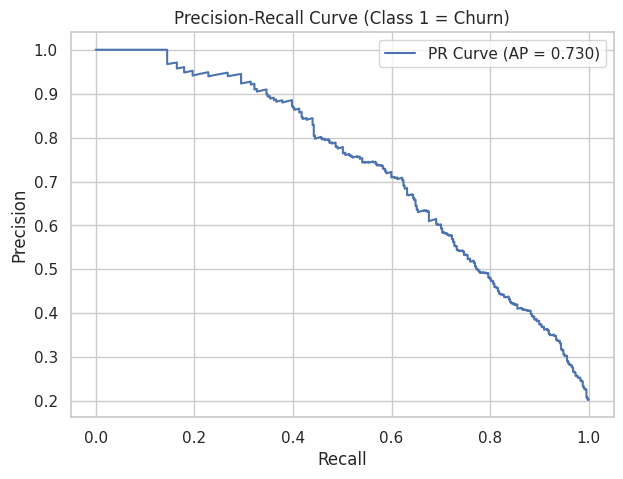


Best threshold for max F1: 0.675

--- Metrics @ TUNED threshold (0.675) ---
Accuracy : 0.8710
Precision: 0.7087
Recall   : 0.6216
F1 Score : 0.6623
ROC-AUC  : 0.8770

               precision    recall  f1-score   support

           0       0.91      0.93      0.92      1593
           1       0.71      0.62      0.66       407

    accuracy                           0.87      2000
   macro avg       0.81      0.78      0.79      2000
weighted avg       0.87      0.87      0.87      2000



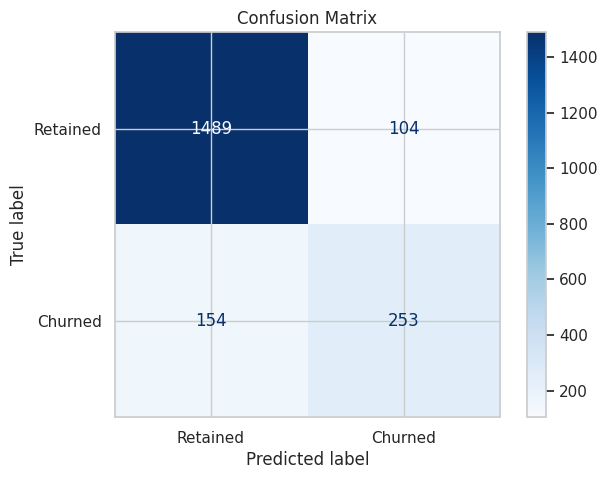

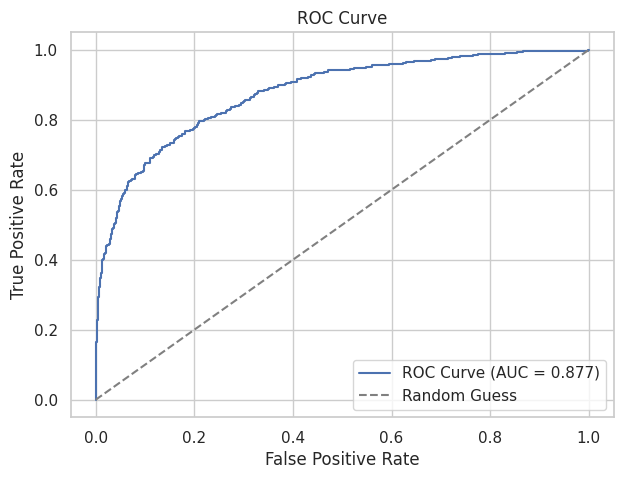

In [36]:
# CELL 8: MODEL EVALUATION
# =====m======================================================

# --- 8.1 Predictions ---
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (churn)

'''# --- 8.2 Core classification metrics ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\nFull classification report:\n", classification_report(y_test, y_pred))
'''
roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- 8.3 Precision-Recall curve + threshold tuning ---
# WHY: the 0.5 cutoff is arbitrary and doesn't reflect your data's
# imbalance. Scanning thresholds finds the cutoff that maximizes F1
# (best precision/recall balance) instead of using a default guess.
# PR curve is also more informative than ROC-AUC here since it
# focuses purely on the minority churn class.
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

plt.figure()
plt.plot(recalls, precisions, label=f"PR Curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Class 1 = Churn)")
plt.legend()
plt.show()

# precision_recall_curve returns len(thresholds) = len(precisions) - 1,
# so align arrays before computing F1 at each cutoff.
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold for max F1: {best_threshold:.3f}")

# --- 8.4 Final predictions using the TUNED threshold ---
# From here on, y_pred is overwritten to reflect the tuned cutoff -
# this becomes the "official" prediction used in the rest of the
# evaluation (confusion matrix, report) below.
y_pred = (y_pred_proba >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# roc_auc is threshold-independent, so it stays the same as above

print(f"\n--- Metrics @ TUNED threshold ({best_threshold:.3f}) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\n", classification_report(y_test, y_pred))

# NOTE: "Best F1 threshold" is a good general-purpose default, but if
# your assignment/business case cares more about catching every churner
# (recall priority) or minimizing false alarms (precision priority),
# manually pick a threshold further left/right on the PR curve instead
# by inspecting the `precisions`/`recalls`/`thresholds` arrays above.

# --- 8.3 Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# --- 8.4 ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()




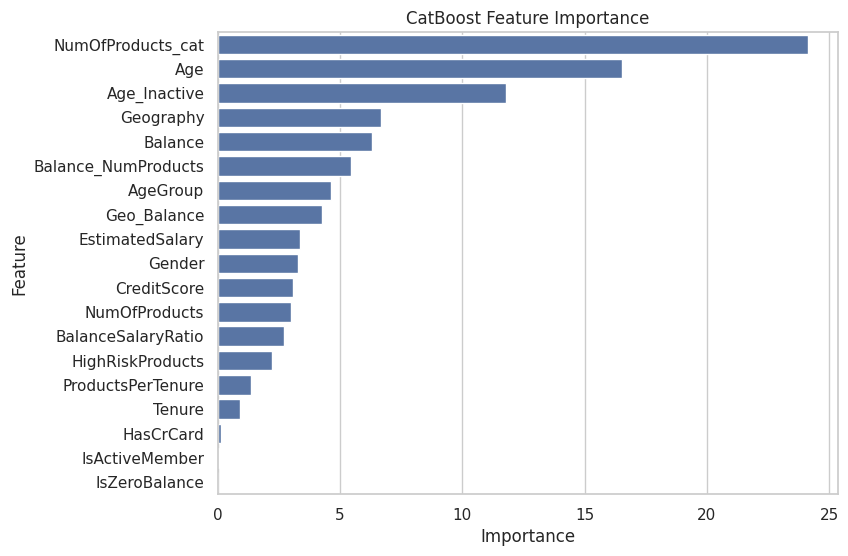

            Feature  Importance
      IsZeroBalance    0.000000
     IsActiveMember    0.062702
          HasCrCard    0.139505
             Tenure    0.930622
  ProductsPerTenure    1.363754
   HighRiskProducts    2.206791
 BalanceSalaryRatio    2.730152
      NumOfProducts    2.998580
        CreditScore    3.072372
             Gender    3.293772
    EstimatedSalary    3.359228
        Geo_Balance    4.285801
           AgeGroup    4.635827
Balance_NumProducts    5.450594
            Balance    6.314112
          Geography    6.678879
       Age_Inactive   11.789675
                Age   16.546520
  NumOfProducts_cat   24.141114


In [37]:
# ======================n======================================
# CELL 8B: FEATURE IMPORTANCE ANALYSIS
# ============================================================
# Separated from evaluation into its own cell for clarity - this
# shows which features the trained model actually relies on most,
# useful both for model trust and for deciding what to prune/keep.

importances = model.get_feature_importance()
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("CatBoost Feature Importance")
plt.show()

print(feat_imp_df.sort_values(by='Importance', ascending=True).to_string(index=False))

In [38]:
# CELL 9: 5-FOLD CROSS VALIDATION
# ============================================================
# StratifiedKFold preserves class ratio in every fold - essential
# for imbalanced data, unlike plain KFold.

# TUNED hyperparameters from Cell 7 and the TUNED threshold from
# Cell 8, so this CV reflects your actual final model setup.

# Note: sklearn's cross_val_score needs a fresh, unfitted CatBoost
# instance with cat_features specified via the Pool or explicitly.
from catboost import Pool

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracies, cv_f1s, cv_aucs = [], [], []
best_params = grid_search.best_params_  # reuse tuned params from Cell 7

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    fold_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        #learning_rate=best_params['learning_rate'],
        l2_leaf_reg=best_params['l2_leaf_reg'],
        bagging_temperature=best_params['bagging_temperature'],  # new - matches Cell 7's expanded grid
        random_strength=best_params['random_strength'],          # new - matches Cell 7's expanded grid
        #depth=6,
        depth=best_params['depth'],
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced', # replaces class_weights list (avoids clone issues elsewhere + simpler)
        #class_weights=[1, y_tr.value_counts()[0] / y_tr.value_counts()[1]],
        random_seed=42,
        verbose=0
    )
    fold_model.fit(X_tr, y_tr, cat_features=cat_feature_indices)

    '''val_pred = fold_model.predict(X_val)
    val_proba = fold_model.predict_proba(X_val)[:, 1]'''
    val_proba = fold_model.predict_proba(X_val)[:, 1]
    val_pred = (val_proba >= best_threshold).astype(int)   # apply the SAME tuned threshold from Cell 8

    cv_accuracies.append(accuracy_score(y_val, val_pred))
    cv_f1s.append(f1_score(y_val, val_pred))
    cv_aucs.append(roc_auc_score(y_val, val_proba))

    print(f"Fold {fold}: Accuracy={cv_accuracies[-1]:.4f}, "
          f"F1={cv_f1s[-1]:.4f}, AUC={cv_aucs[-1]:.4f}")

print("\n--- 5-Fold CV Summary ---")
print(f"Mean Accuracy: {np.mean(cv_accuracies):.4f} (+/- {np.std(cv_accuracies):.4f})")
print(f"Mean F1 Score: {np.mean(cv_f1s):.4f} (+/- {np.std(cv_f1s):.4f})")
print(f"Mean ROC-AUC : {np.mean(cv_aucs):.4f} (+/- {np.std(cv_aucs):.4f})")

Fold 1: Accuracy=0.8590, F1=0.6347, AUC=0.8697
Fold 2: Accuracy=0.8480, F1=0.5957, AUC=0.8555
Fold 3: Accuracy=0.8590, F1=0.6430, AUC=0.8697
Fold 4: Accuracy=0.8625, F1=0.6470, AUC=0.8723
Fold 5: Accuracy=0.8665, F1=0.6482, AUC=0.8793

--- 5-Fold CV Summary ---
Mean Accuracy: 0.8590 (+/- 0.0062)
Mean F1 Score: 0.6337 (+/- 0.0196)
Mean ROC-AUC : 0.8693 (+/- 0.0077)


In [39]:
# CELL 10 (OPTIONAL): Save Trained Model to Drive
# ============================================================
'''model.save_model('/content/drive/MyDrive/AI&ML project/Colab Notebooks/catboost_churn_model.cbm')
print("Tuned model saved to Drive.")'''

'model.save_model(\'/content/drive/MyDrive/AI&ML project/Colab Notebooks/catboost_churn_model.cbm\')\nprint("Tuned model saved to Drive.")'